## VIT (Vision Transformer)

In [1]:
import torch
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import requests
import matplotlib.pyplot as plt

# 1. 모델 및 프로세서 로드  
model_name = "google/vit-base-patch16-224" # https://huggingface.co/google/vit-base-patch16-224
processor = ViTImageProcessor.from_pretrained(model_name)       # 이미지 정규화 전처리
model = ViTForImageClassification.from_pretrained(model_name)


c:\ProgramData\miniconda3\envs\venv_lmm\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# 2. 테스트용 이미지 로드 (COCO 데이터셋의 고양이 사진)
url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)

# 3. 이미지 전처리 및 텐서 변환
inputs = processor(images=image, return_tensors="pt")

# 4. 모델 추론 (Forward Pass)
model.eval()
with torch.no_grad():
    outputs = model(**inputs)



상위 7개 예측 결과:
Egyptian cat: 93.74%
tabby, tabby cat: 3.84%
tiger cat: 1.44%
lynx, catamount: 0.33%
Siamese cat, Siamese: 0.07%
Persian cat: 0.01%
snow leopard, ounce, Panthera uncia: 0.01%


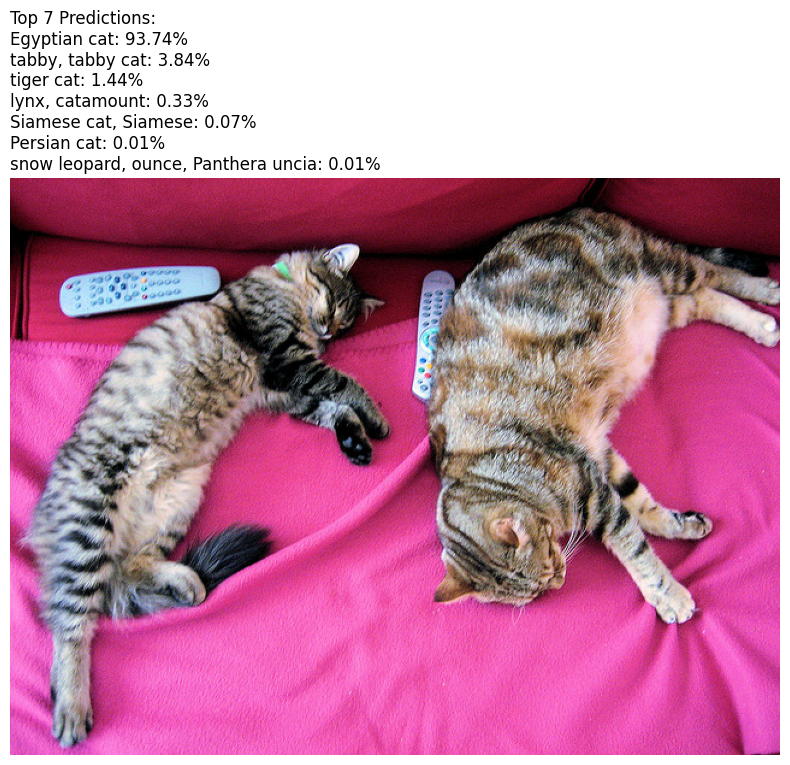

In [ ]:
# 5. 결과 확인 및 상위 k개 클래스 확률 추출
k = 7
logits = outputs.logits
probs = torch.nn.functional.softmax(logits, dim=-1)[0]
top_probs, top_catids = torch.topk(probs, k)

print(f"\n상위 {k}개 예측 결과:")
title_text = f"Top {k} Predictions:\n"
for i in range(top_probs.size(0)):
    prob = top_probs[i].item() * 100
    class_name = model.config.id2label[top_catids[i].item()]
    line = f"{class_name}: {prob:.2f}%"
    print(line)
    title_text += line + "\n"

# 6. 이미지와 예측 결과 시각화
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title(title_text.strip(), loc='left', fontsize=12)
plt.axis('off') 
plt.tight_layout()
plt.show()